# Air Pollution Project


## Load Data and Libraries


In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

# Import airpollution data
df_ap = pd.read_csv("data/Train.csv")

df_ap.info()
df_ap.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


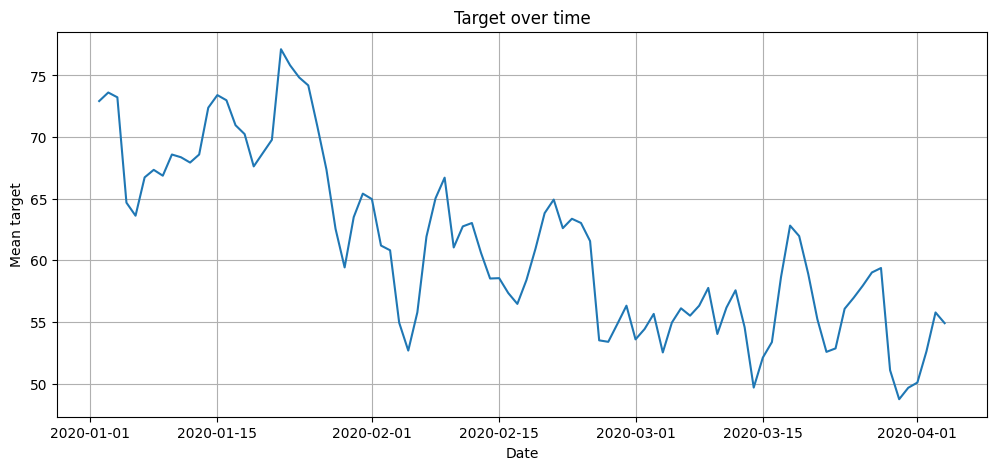

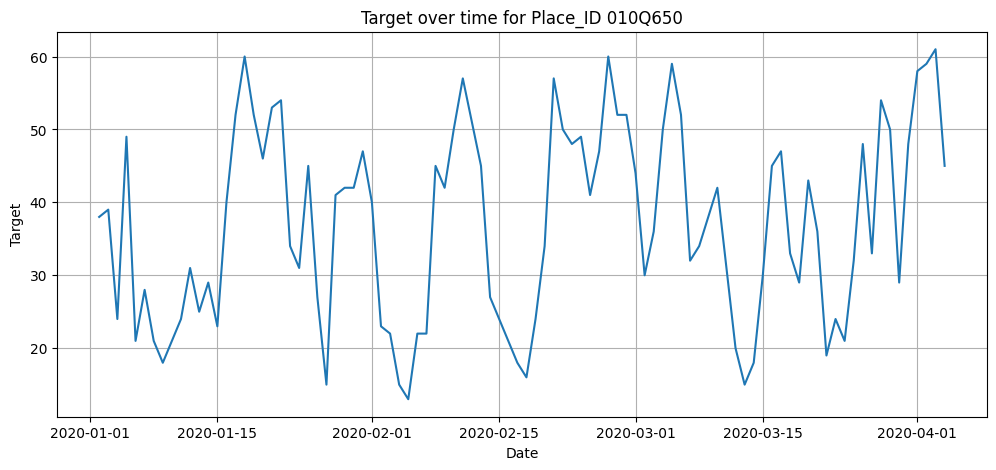

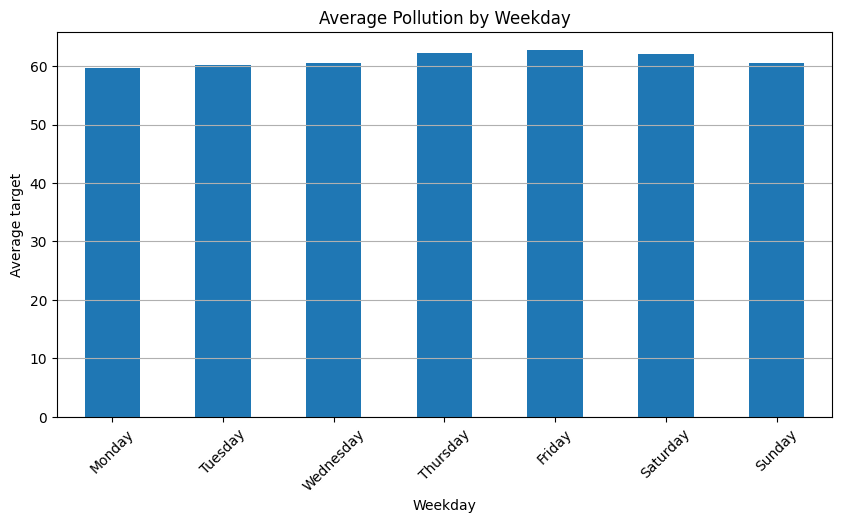

In [2]:
#visualizing the target over time
df_ap['Date'] = pd.to_datetime(df_ap['Date'])

target_by_date = df_ap.groupby('Date')['target'].mean()

plt.figure(figsize=(12, 5))
plt.plot(target_by_date.index, target_by_date.values)
plt.title('Target over time')
plt.xlabel('Date')
plt.ylabel('Mean target')
plt.grid(True)
plt.show()
place_id = '010Q650'

df_place = df_ap[df_ap['Place_ID'] == place_id].copy()
df_place['Date'] = pd.to_datetime(df_place['Date'])

plt.figure(figsize=(12, 5))
plt.plot(df_place['Date'], df_place['target'])
plt.title(f'Target over time for Place_ID {place_id}')
plt.xlabel('Date')
plt.ylabel('Target')
plt.grid(True)
plt.show()
df_ap['Date'] = pd.to_datetime(df_ap['Date'])

weekday_pollution = (
    df_ap
    .assign(weekday=df_ap['Date'].dt.day_name())
    .groupby('weekday')['target']
    .mean()
)

weekday_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

weekday_pollution = weekday_pollution.reindex(weekday_order)

plt.figure(figsize=(10, 5))
weekday_pollution.plot(kind='bar')
plt.title('Average Pollution by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average target')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## Missing Values and Feature Setup


In [3]:
# Checking for missing values
missing = pd.DataFrame(df_ap.isnull().sum(), columns=["Amount"])
missing['Percentage'] = round((missing['Amount'] / df_ap.shape[0]) * 100, 2)
missing[missing['Amount'] != 0]

# Get columns where missing data is 80% or more
cols_high_missing = df_ap.columns[df_ap.isnull().mean() >= 0.8].tolist()
print(cols_high_missing)

# Drop leakage columns
leakage_cols = ['target_min', 'target_max', 'target_variance', 'target_count']

# Drop columns with 80%+ missing
high_missing_cols = df_ap.columns[df_ap.isnull().mean() >= 0.8].tolist()

# convert date columns to date value
df_ap['Date'] = pd.to_datetime(df_ap['Date'])
df_ap['day_number'] = (df_ap['Date'] - df_ap['Date'].min()).dt.days + 1
df_ap['month'] = df_ap['Date'].dt.month
df_ap['day_of_week'] = df_ap['Date'].dt.dayofweek


['L3_CH4_CH4_column_volume_mixing_ratio_dry_air', 'L3_CH4_aerosol_height', 'L3_CH4_aerosol_optical_depth', 'L3_CH4_sensor_azimuth_angle', 'L3_CH4_sensor_zenith_angle', 'L3_CH4_solar_azimuth_angle', 'L3_CH4_solar_zenith_angle']


## Location-Based Validation Split


In [4]:
# Get unique Place_IDs
places = df_ap['Place_ID'].unique()
print(f"Total unique places: {len(places)}")

# Split place IDs into train and validation sets
from sklearn.model_selection import train_test_split

places_train, places_val = train_test_split(places, test_size=0.2, random_state=42)

# Filter rows based on place membership
train_split = df_ap[df_ap['Place_ID'].isin(places_train)]
val_split = df_ap[df_ap['Place_ID'].isin(places_val)]

print(f"Train rows: {len(train_split)}, Places: {len(places_train)}")
print(f"Val rows:   {len(val_split)},  Places: {len(places_val)}")

removed_cols = ['Place_ID X Date', 'Date', 'Place_ID']
drop_cols = leakage_cols + high_missing_cols + removed_cols

X_tr = train_split.drop(columns=drop_cols + ['target'])
y_tr = train_split['target']

X_val = val_split.drop(columns=drop_cols + ['target'])
y_val = val_split['target']

print('X_tr shape:', X_tr.shape)
print('X_val shape:', X_val.shape)
print('y_tr shape:', y_tr.shape)
print('y_val shape:', y_val.shape)


Total unique places: 340
Train rows: 24546, Places: 272
Val rows:   6011,  Places: 68
X_tr shape: (24546, 70)
X_val shape: (6011, 70)
y_tr shape: (24546,)
y_val shape: (6011,)


## Training Data Checks


L3_NO2_tropospheric_NO2_column_number_density          0.273201
L3_HCHO_sensor_azimuth_angle                           0.236087
L3_HCHO_tropospheric_HCHO_column_number_density_amf    0.236087
L3_HCHO_tropospheric_HCHO_column_number_density        0.236087
L3_HCHO_solar_zenith_angle                             0.236087
                                                         ...   
L3_AER_AI_sensor_altitude                              0.006355
L3_AER_AI_sensor_azimuth_angle                         0.006355
L3_AER_AI_sensor_zenith_angle                          0.006355
L3_AER_AI_solar_azimuth_angle                          0.006355
L3_AER_AI_solar_zenith_angle                           0.006355
Length: 61, dtype: float64
float64    67
int32       2
int64       1
Name: count, dtype: int64
[]
                                             min         max        mean   
precipitable_water_entire_atmosphere    0.420044   72.599998   15.168951  \
relative_humidity_2m_above_ground       6.8000

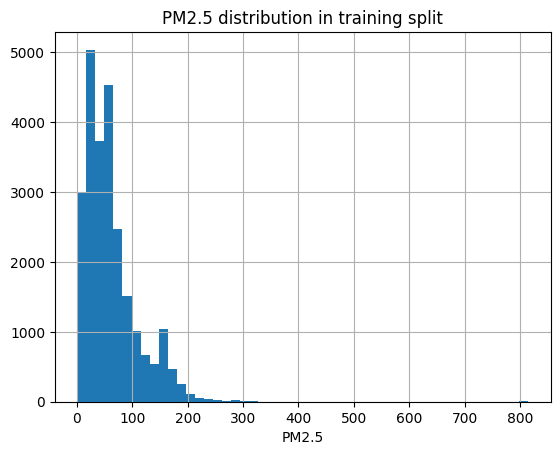

count    24546.000000
mean        62.030995
std         47.960782
min          1.000000
25%         26.000000
50%         51.000000
75%         80.000000
max        815.000000
Name: target, dtype: float64


In [5]:
# Cleaning the training data set first:
# Check for missing values:
missing = X_tr.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0])

# Check for data types
print(X_tr.dtypes.value_counts())

# Check if any non-numeric columns slipped through
print(X_tr.select_dtypes('object').columns.tolist())

# We look for outliers
print(X_tr.describe().T[['min', 'max', 'mean', 'std']])

# Looking for duplicate rows in train data set
print(f"Duplicate rows: {X_tr.duplicated().sum()}")

y_tr.hist(bins=50)
plt.title("PM2.5 distribution in training split")
plt.xlabel("PM2.5")
plt.show()

print(y_tr.describe())


## Imputation and Outlier Handling


In [6]:
# Clean the training data only first:
imputer = SimpleImputer(strategy='median')
X_tr_imputed = pd.DataFrame(imputer.fit_transform(X_tr), columns=X_tr.columns)
X_val_imputed = pd.DataFrame(imputer.transform(X_val), columns=X_tr.columns)

# Verify no missing values remain
print(X_tr_imputed.isnull().sum().sum())   # should be 0
print(X_val_imputed.isnull().sum().sum())  # should be 0

# Quantify the outliers in training data using IQR
Q1 = X_tr_imputed.quantile(0.25)
Q3 = X_tr_imputed.quantile(0.75)
IQR = Q3 - Q1

# Count outliers per column
outlier_counts = ((X_tr_imputed < (Q1 - 1.5 * IQR)) |
                  (X_tr_imputed > (Q3 + 1.5 * IQR))).sum()

print(outlier_counts.sort_values(ascending=False))

# Dealing with the outliers by clipping the IQR bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X_tr_clipped = X_tr_imputed.clip(lower=lower, upper=upper, axis=1)

# Apply same bounds to validation (computed from train only!)
X_val_clipped = X_val_imputed.clip(lower=lower, upper=upper, axis=1)

# Verify results
# Recheck outlier count should be 0 after clipping
outlier_counts_after = ((X_tr_clipped < (Q1 - 1.5 * IQR)) |
                        (X_tr_clipped > (Q3 + 1.5 * IQR))).sum()
print(outlier_counts_after.sum())  # should be 0


0
0
L3_CO_solar_azimuth_angle                 4715
L3_HCHO_solar_azimuth_angle               4637
L3_SO2_solar_azimuth_angle                4581
L3_NO2_NO2_slant_column_number_density    3895
L3_SO2_SO2_column_number_density          3865
                                          ... 
L3_NO2_tropopause_pressure                   0
L3_NO2_sensor_zenith_angle                   0
L3_NO2_sensor_azimuth_angle                  0
L3_NO2_cloud_fraction                        0
day_of_week                                  0
Length: 70, dtype: int64
0


## Target Skewness


In [7]:
#Handle target skewnes

## Save Cleaned Data


In [8]:
# Save cleaned train and validation data for model training
clean_train = X_tr_clipped.copy()
clean_train['target'] = y_tr.reset_index(drop=True)

clean_val = X_val_clipped.copy()
clean_val['target'] = y_val.reset_index(drop=True)

clean_train.to_csv('data/clean_train.csv', index=False)
clean_val.to_csv('data/clean_val.csv', index=False)

print('Saved cleaned data:')
print('data/clean_train.csv', clean_train.shape)
print('data/clean_val.csv', clean_val.shape)


Saved cleaned data:
data/clean_train.csv (24546, 71)
data/clean_val.csv (6011, 71)
